### Human In the Loop
Review
For human-in-the-loop, we often want to see our graph outputs as its running.

We laid the foundations for this with streaming.

Goals
Now, let's talk about the motivations for human-in-the-loop:

(1) Approval - We can interrupt our agent, surface state to a user, and allow the user to accept an action

(2) Debugging - We can rewind the graph to reproduce or avoid issues

(3) Editing - You can modify the state

LangGraph offers several ways to get or update agent state to support various human-in-the-loop workflows.

In [101]:
import os
from dotenv import load_dotenv

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="llama-3.1-8b-instant")

In [102]:
### Def custom tools
def multiply(a:int, b:int) -> int:
    """Mutiliply a and b
    Args:
        a: int
        b: int
    Returns:
        int
    """
    return a * b

def add(a:int, b:int) -> int:
    """Add a and b
    Args:
        a: int
        b: int
    Returns:
        int
    """
    return a + b

def divide(a:int, b:int) -> int:
    """Divide a by b
    Args:
        a: int
        b: int
    Returns:
        int
    """ 
    return a / b

In [103]:
# Bind the tools to the LLM
tools = [multiply, add, divide]
print(tools)

llm_with_tools = llm.bind_tools(tools)

llm_with_tools





[<function multiply at 0x000001A10069E7A0>, <function add at 0x000001A100797600>, <function divide at 0x000001A100795DA0>]


RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001A17EEDE000>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001A17EEC3320>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Mutiliply a and b\nArgs:\n    a: int\n    b: int\nReturns:\n    int', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'add', 'description': 'Add a and b\nArgs:\n    a: int\n    b

In [104]:
### WWorkflow with Langgraph
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

In [105]:
## System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")



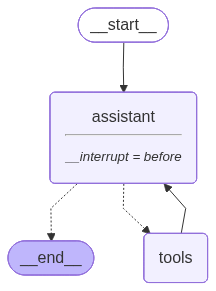

In [106]:
## Node definition
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

## Define nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

## Define edges
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,

)

builder.add_edge("tools","assistant")

memory=MemorySaver()

### human in the loop
graph=builder.compile(interrupt_before=["assistant"],checkpointer=memory)

# Show
display(Image(graph.get_graph().draw_mermaid_png()))

In [107]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [108]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


you can see above that the only message printed is the Human message and then nothing appeared, this is because the intruption process. the interuption happens before the assistant itself

In [109]:
state = graph.get_state(thread)
 ## means the next event in the graph is the assistant node,  so the interruption happens before the assistant node and the Human message stoppend before hitting the assistant node
state.next

('assistant',)

In [110]:
# current state
state # means the current state of the graph and where it is in the graph

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='eee4d202-5add-4745-9426-a2bb36555850')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f150e75-b83d-608f-8000-78b52b352f9c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-16T05:23:22.822875+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f150e75-b83a-6991-bfff-2d79d07e89d1'}}, tasks=(PregelTask(id='4ef94aad-1f00-8502-e029-b191538b65d4', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [111]:
state.next

('assistant',)

In [112]:
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x000001A17C591220>

In [113]:
## Continue the execution to Assistant. None means the input is not provided, so the graph will continue to execute
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (j4ma92d81)
 Call ID: j4ma92d81
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [114]:
state=graph.get_state(thread)
state.next # After generating a response, the next event is the assistant node

('assistant',)

In [115]:
## Continue the execution of Assistant and then end, and the LLM will generate a final response
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


## Edit Human Feedback

In [116]:
initial_input= {
    "messages": HumanMessage(content="Multiply 2 and 3")
}

thread={"configurable":{"thread_id":"1"}}
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [117]:
state=graph.get_state(thread)
state.next

('assistant',)

In [118]:
graph.update_state(thread,{"messages":[HumanMessage(content="No,please multiply 15 and 6")]})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f150e75-bcc7-6f46-8001-8cd69407c8bc'}}

In [119]:
new_state=graph.get_state(thread).values

for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No,please multiply 15 and 6


In [120]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No,please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (z5wmx0qgr)
 Call ID: z5wmx0qgr
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


In [121]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

Since the function 'multiply' returns an integer, the result is 90.
